In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [46]:
df = pd.read_csv("Student_performance_data _.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [47]:
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns)

Dimensions : (2392, 15)

Colonnes :
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [48]:
tutor_mean = df.groupby("Tutoring")["GPA"].mean()
print(tutor_mean)

Tutoring
0    1.818968
1    2.108325
Name: GPA, dtype: float64


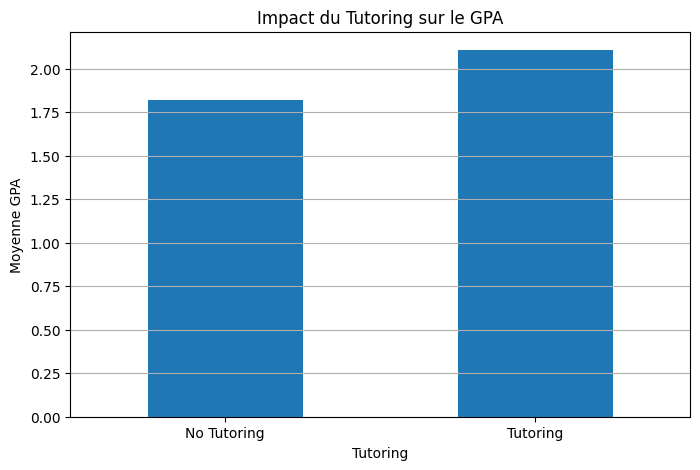

In [49]:
plt.figure(figsize=(8,5))
tutor_mean.plot(kind="bar")

plt.title("Impact du Tutoring sur le GPA")
plt.ylabel("Moyenne GPA")
plt.xticks([0,1], ["No Tutoring", "Tutoring"], rotation=0)
plt.grid(axis="y")
plt.show()

In [50]:
group_tutoring = df[df["Tutoring"] == 1]["GPA"]
group_no_tutoring = df[df["Tutoring"] == 0]["GPA"]

anova = stats.f_oneway(group_tutoring, group_no_tutoring)

print("F-statistic :", anova.statistic)
print("P-value :", anova.pvalue)

F-statistic : 51.41498107077686
P-value : 9.923854014280635e-13


In [51]:
if anova.pvalue < 0.05:
    print("✅ Le tutoring influence significativement le GPA")
else:
    print("❌ Pas d'effet significatif")

✅ Le tutoring influence significativement le GPA


In [52]:
gender_perf = df.groupby("Gender")["GPA"].mean()
print(gender_perf)

Gender
0    1.918679
1    1.894225
Name: GPA, dtype: float64


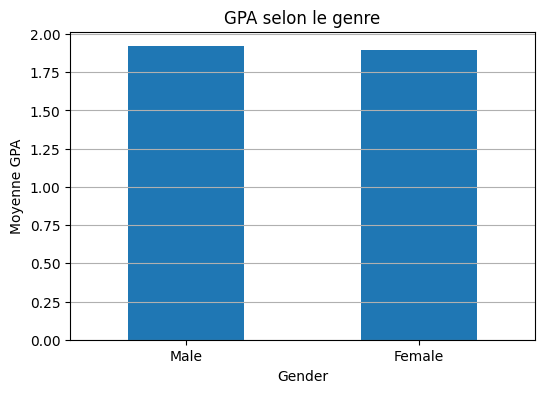

In [53]:
plt.figure(figsize=(6,4))
gender_perf.plot(kind="bar")

plt.title("GPA selon le genre")
plt.ylabel("Moyenne GPA")
plt.xticks([0,1], ["Male", "Female"], rotation=0)
plt.grid(axis="y")
plt.show()

In [54]:
parent_perf = df.groupby("ParentalEducation")["GPA"].mean()
print(parent_perf)

ParentalEducation
0    1.893045
1    1.944022
2    1.929881
3    1.809082
4    1.815812
Name: GPA, dtype: float64


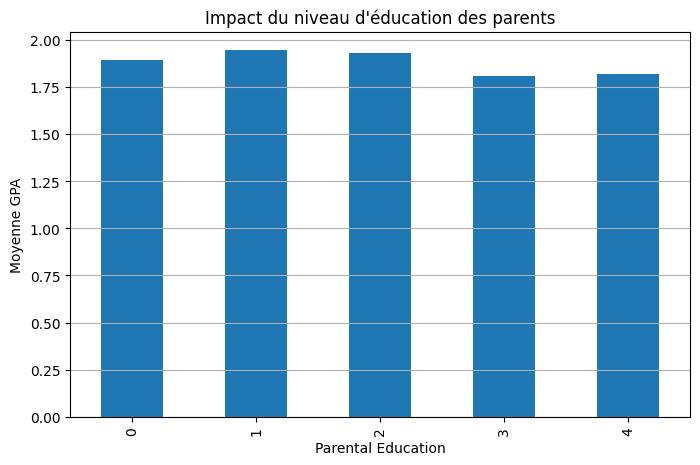

In [55]:
plt.figure(figsize=(8,5))
parent_perf.plot(kind="bar")

plt.title("Impact du niveau d'éducation des parents")
plt.ylabel("Moyenne GPA")
plt.xlabel("Parental Education")
plt.grid(axis="y")
plt.show()

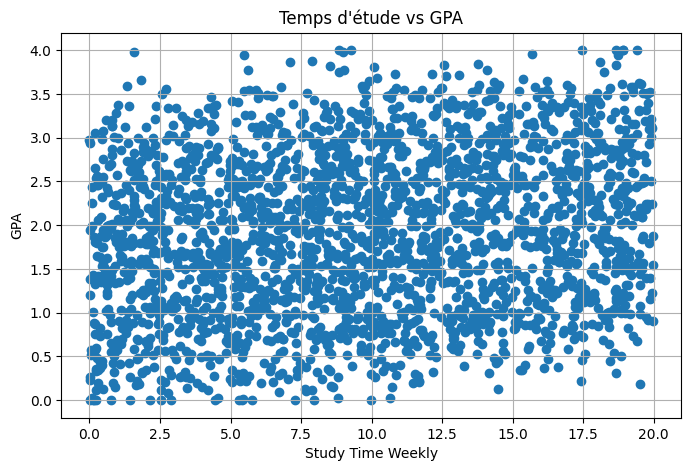

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(df["StudyTimeWeekly"], df["GPA"])

plt.title("Temps d'étude vs GPA")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.grid()
plt.show()

In [57]:
corr = df[["StudyTimeWeekly", "Absences", "ParentalSupport", "GPA"]].corr()
print(corr)

                 StudyTimeWeekly  Absences  ParentalSupport       GPA
StudyTimeWeekly         1.000000  0.009326         0.035800  0.179275
Absences                0.009326  1.000000         0.002108 -0.919314
ParentalSupport         0.035800  0.002108         1.000000  0.190774
GPA                     0.179275 -0.919314         0.190774  1.000000


In [58]:
print("""
Conclusion :
- Le tutoring améliore le GPA
- Plus le temps d'étude augmente, plus le GPA augmente
- Les absences réduisent les performances
- Le soutien parental améliore les résultats
""")


Conclusion :
- Le tutoring améliore le GPA
- Plus le temps d'étude augmente, plus le GPA augmente
- Les absences réduisent les performances
- Le soutien parental améliore les résultats



In [ ]:
from google.colab import drive
drive.mount('/content/drive')